### Imports and settings

In [ ]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from pathlib import Path
import colorcet as cc
import calendar
from scipy import stats
from importlib import reload
import dyndowntools.util as du
import pymannkendall as mk

In [ ]:
reload(du)

<module 'dyndowntools.util' from '/Users/chris/Projects/dyndowntools/dyndowntools/util.py'>

In [ ]:
datadir = Path().absolute().parent / "evaluation/working"
figdir = Path().absolute().parent / "evaluation/figures"
stationdir = Path().absolute().parent / "evaluation/weatherstationdata/ACIS"
filepattern_ERA5_dscale = 't2m_{agg}_{airport}_1981_2020_{resolution}.csv'
filepattern_ERA5_orig = 'era5_{airport}_Tmean_1981_2020_monthly.csv'
filepattern_station = "{station}_T_max_min_avg_pcpn_sd_swe.csv"

In [ ]:
stations = {
    "ANCHORAGE_TED_STEVENS_INTERNATIONAL_AIRPORT": "ANC_PANC",
    "FAIRBANKS_INTL_AP": "FAI_PAFA",
    "BARROW_AIRPORT": "UTQ_PABR",
    "BETHEL_AIRPORT": "BTH_PABE"
}
startdate = '1981-01-01'
enddate = '2020-12-31'
var = 'T2'
agg = 'mean'
fullnames = list(stations.keys())
resolutions = ['4km', '12km']

In [ ]:
month_abbr = [calendar.month_abbr[ii] for ii in range(1, 13)]
month_initials = [item[0] for item in month_abbr]
month_initials

['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

### Functions

In [ ]:
def get_dataframe_ERA5(station, startdate=startdate, enddate=enddate):
    dfs = {}
    var = f'T2_{agg}'
    for res in resolutions:
        dfs[res] = pd.read_csv(
            datadir / filepattern_ERA5_dscale.format(airport=stations[station], agg=agg, resolution=res))
        dfs[res]['Time'] = pd.to_datetime(dfs[res]['Time'])
        dfs[res][var] = dfs[res][var] - 273.15      # K to C
        dfs[res].rename(columns={var: f"{var}_{res}"}, inplace=True)
        # dfs[res].set_index('Time')
    dfs['4km'][f'{var}_12km'] = dfs['12km'][f'{var}_12km']
    return dfs['4km']

def get_dataframe_station(station, startdate=startdate, enddate=enddate):
    stationpth = stationdir / filepattern_station.format(station=station)
    df = du.station2df(stationpth)
    # return df
    if agg=='max':
        df['Tmax_station'] = du.F2C(df['Tmax_F'].astype(float))
        return df['Tmax_station'].loc[startdate:enddate]
    elif agg=='mean':
        df['Tmean_station'] = du.F2C(df['Tavg_F'])
        return df['Tmean_station'].loc[startdate:enddate]
    return df.loc[startdate:enddate]

def get_dataframe(station, startdate=startdate, enddate=enddate):
    ERA5df = get_dataframe_ERA5(station, startdate=startdate, enddate=enddate)
    stationdf = get_dataframe_station(station, startdate=startdate, enddate=enddate)
    ERA5df.set_index('Time', inplace=True)
    ERA5df.index = pd.to_datetime(ERA5df.index)
    stationdf.index.name = 'Time'
    stationdf.index = pd.to_datetime(stationdf.index)

    return pd.merge(ERA5df, stationdf,
            how='inner', left_index=True, right_index=True)

In [ ]:
def get_stats(teststation, monthlyDF, kind='linear'):
    output = []
    for variable in (f'T{agg}_orig', f'T2_{agg}_4km', f'T2_{agg}_12km', f'T{agg}_station'):
        for mth in range(1, 13):
            X = monthlyDF.query(f'month == {mth}')['year']
            Z = monthlyDF.query(f'month == {mth}')[f'T{agg}_station']
            Y = monthlyDF.query(f'month == {mth}')[variable]
            r_value, tau_value, rmse, bias = None, None, None, None
            if kind=='linear':
                slope, _, r_value, p_value, _ = stats.linregress(X, Y)
            elif kind=='mannkendall':
                _, _, p_value, _, tau_value, _, _, slope, _ = mk.original_test(Y)
            mean = Y.mean()
            std = Y.std()
            if variable != f'T{agg}_station':
                rmse = du.rmse(Y, Z)
                bias = (Y-Z).mean()
            output.append({
                "location": stations[teststation][4:],
                'variable': variable,
                'month': mth, 
                'mean_monthly': mean, 
                'std_monthly': std,
                'rmse_monthly': rmse,
                'bias_monthly': bias,
                'trend': slope, 
                'p_value': p_value, 
                'kendall_tau': tau_value,
                'r_value':r_value})
    return output

In [ ]:
def get_monthly(dailyDF):
    # dailyDF = dailyDF.loc[startdate:enddate]
    monthly_avg = dailyDF[[f'T2_{agg}_4km', f'T2_{agg}_12km', f'T{agg}_station']].groupby(
        pd.Grouper(freq='M')).mean()
    monthly_avg['year'] = monthly_avg.index.year
    monthly_avg['month'] = monthly_avg.index.month
    return monthly_avg

In [ ]:
def get_name(location):
    name = location.split(' ')[0].title()
    if name == 'Barrow':
        return 'Utqiaġvik'
    else:
        return name

In [ ]:
def add_significance_suffix(p_value):
    if p_value < 0.05:
        return ' (**)'
    elif p_value < 0.1:
        return ' (*)'
    else: return ''

### Single location prototyping

In [ ]:
teststation = 'BETHEL_AIRPORT'
du.get_dataframe('T2', teststation)

var is T2
var is T2
in /Users/chris/Projects/dyndowntools/dyndowntools/util.py. var is T2


,T2_mean_4km,T2_mean_12km,Tmean_station
Time,,,
1981-01-01,0.119,0.079,-0.833333
1981-01-02,-8.863,-8.915,-4.166667
1981-01-03,-3.553,-3.559,-4.444444
1981-01-04,-0.394,-0.386,-2.777778
1981-01-05,-1.216,-1.604,-2.222222
...,...,...,...
2020-12-27,-1.615,-1.773,-3.055556
2020-12-28,0.156,-0.579,-0.555556
2020-12-29,-0.273,-0.313,-1.388889


In [ ]:
compDF = du.get_dataframe(var, teststation)
monthly_DF = du.get_monthly(var, compDF)
monthly_undownscaled = pd.read_csv(datadir / filepattern_ERA5_orig.format(
    airport=stations[teststation][4:]), skiprows=2)
monthly_DF['Tmean_orig'] = monthly_undownscaled['t2m'].values 
monthly_DF

var is T2
var is T2
in /Users/chris/Projects/dyndowntools/dyndowntools/util.py. var is T2


/Users/chris/Projects/dyndowntools/dyndowntools/util.py:125: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()


,T2_mean_4km,T2_mean_12km,Tmean_station,year,month,Tmean_orig
Time,,,,,,
1981-01-31,-6.313000,-6.329065,-6.191756,1981,1,-5.198
1981-02-28,-13.875893,-14.127536,-10.902778,1981,2,-10.301
1981-03-31,-3.934419,-3.968516,-1.424731,1981,3,-0.923
1981-04-30,-3.425200,-2.889567,0.138889,1981,4,0.218
1981-05-31,8.709161,8.905419,8.942652,1981,5,9.469
...,...,...,...,...,...,...
2020-08-31,12.939710,13.169839,13.055556,2020,8,13.280
2020-09-30,7.028133,7.181000,7.407407,2020,9,7.462
2020-10-31,2.076032,2.159710,2.249104,2020,10,2.638


In [ ]:
from sklearn.metrics import root_mean_squared_error

In [ ]:
monthly_DF.groupby('month').apply(lambda df: (df.Tmean_orig-df.T2_mean_12km).mean())

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_68903/2536431396.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_DF.groupby('month').apply(lambda df: (df.Tmean_orig-df.T2_mean_12km).mean())


month
1     1.010749
2     1.369081
3     2.094425
4     1.812034
5     0.588056
6     0.169877
7     0.245665
8     0.437479
9     0.556742
10    0.565077
11    0.464466
12    0.714188
dtype: float64

In [ ]:
monthly_DF.groupby('month').apply(lambda df: root_mean_squared_error(df.T2_mean_4km, df.Tmean_orig))

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_68903/2386846130.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_DF.groupby('month').apply(lambda df: root_mean_squared_error(df.T2_mean_4km, df.Tmean_orig))


month
1     1.280199
2     1.594627
3     2.374651
4     2.199986
5     0.922488
6     0.468828
7     0.508032
8     0.660098
9     0.734473
10    0.718522
11    0.732255
12    0.915689
dtype: float64

In [ ]:
monthly_DF.groupby('month').apply(lambda df: root_mean_squared_error(df.Tmean_station, df.Tmean_orig))

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_68903/1248213877.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_DF.groupby('month').apply(lambda df: root_mean_squared_error(df.Tmean_station, df.Tmean_orig))


month
1     0.813000
2     0.738089
3     0.861433
4     1.018455
5     0.723089
6     0.435560
7     0.304479
8     0.292773
9     0.318696
10    0.506254
11    0.723696
12    0.823307
dtype: float64

In [ ]:
((monthly_DF.Tmean_orig - monthly_DF.Tmean_station)**2).mean()

0.4529572198407769

In [ ]:
monthly_DF

,T2_mean_4km,T2_mean_12km,Tmean_station,year,month,Tmean_orig
Time,,,,,,
1981-01-31,-6.313000,-6.329065,-6.191756,1981,1,-5.198
1981-02-28,-13.875893,-14.127536,-10.902778,1981,2,-10.301
1981-03-31,-3.934419,-3.968516,-1.424731,1981,3,-0.923
1981-04-30,-3.425200,-2.889567,0.138889,1981,4,0.218
1981-05-31,8.709161,8.905419,8.942652,1981,5,9.469
...,...,...,...,...,...,...
2020-08-31,12.939710,13.169839,13.055556,2020,8,13.280
2020-09-30,7.028133,7.181000,7.407407,2020,9,7.462
2020-10-31,2.076032,2.159710,2.249104,2020,10,2.638


In [ ]:
get_stats(teststation, monthly_DF, kind='mannkendall')

[{'location': 'PABE',
  'variable': 'Tmean_orig',
  'month': 1,
  'mean_monthly': -13.279675000000001,
  'std_monthly': 5.320430772937035,
  'rmse_monthly': 0.81299959958867,
  'bias_monthly': 0.46796126251390424,
  'trend': -0.0012589605734767148,
  'p_value': 0.9721171358417333,
  'kendall_tau': -0.005128205128205128,
  'r_value': None},
 {'location': 'PABE',
  'variable': 'Tmean_orig',
  'month': 2,
  'mean_monthly': -10.747375,
  'std_monthly': 5.308030721258168,
  'rmse_monthly': 0.738089324447265,
  'bias_monthly': 0.4210277777777779,
  'trend': 0.11433441558441558,
  'p_value': 0.07465008977427945,
  'kendall_tau': 0.19743589743589743,
  'r_value': None},
 {'location': 'PABE',
  'variable': 'Tmean_orig',
  'month': 3,
  'mean_monthly': -8.632825,
  'std_monthly': 3.9164464982580767,
  'rmse_monthly': 0.8614326388105108,
  'bias_monthly': 0.6713864695340505,
  'trend': -0.056625000000000016,
  'p_value': 0.3696497329509345,
  'kendall_tau': -0.1,
  'r_value': None},
 {'location':

In [ ]:
output = []
for mth in range(1, 13):
    X = monthly_DF.query(f'month == {mth}')['year']
    Y = monthly_DF.query(f'month == {mth}')[f'T{agg}']
    slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)
    mean = Y.mean()
    output.append((mth, mean, slope, p_value, r_value, std_err))

In [ ]:
mth = 8
X = monthly_DF.query(f'month == {mth}')['year']
Y = monthly_DF.query(f'month == {mth}')[f'T{agg}']
slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)

In [ ]:
slope, intercept, p_value

(0.02762607879924952, -43.11637063789866, 0.10096687074658861)

In [ ]:
cmap = plt.cm.get_cmap('cet_glasbey')
cmap = plt.cm.get_cmap('Set1')

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_39190/1137458020.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('cet_glasbey')
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_39190/1137458020.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1')


In [ ]:
# monthly_DF.index.name = 'Time'
df_forplot = pd.melt(monthly_DF.reset_index(), id_vars=[monthly_DF.index.name, 'year', 'month'], 
        value_vars=['Tmean_orig', 'T2_mean_12km', 'T2_mean_4km', 'Tmean_station'], value_name='meanT', var_name=teststation)

In [ ]:
# palette = sns.color_palette(cc.b_glasbey_category10, n_colors=4)
palette = sns.color_palette("Set2", 10)
viridis_palette = sns.color_palette("viridis", 25)
# viridis_palette = [viridis_palette[ii] for ii in [14, 8, -1]]
# viridis_palette
palette

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 (1.0, 0.8509803921568627, 0.1843137254901961),
 (0.8980392156862745, 0.7686274509803922, 0.5803921568627451),
 (0.7019607843137254, 0.7019607843137254, 0.7019607843137254),
 (0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961)]

In [ ]:
# palette = palette[[0, 1, 2, 7]]
palette[3] = palette[7]
palette = palette[:4]
palette

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.7019607843137254, 0.7019607843137254, 0.7019607843137254)]

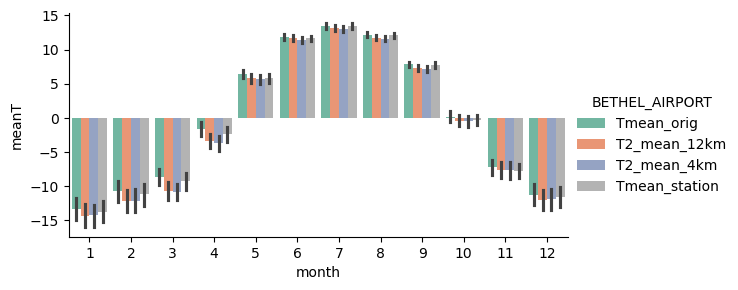

In [ ]:
g = sns.catplot(data=df_forplot, kind="bar", x="month", y="meanT", 
            hue=teststation, palette=palette, width=0.85, height=3, aspect=2)
# g._legend.remove()

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_68903/3433591431.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)


Text(0.5, 1.0, 'BETHEL_AIRPORT')

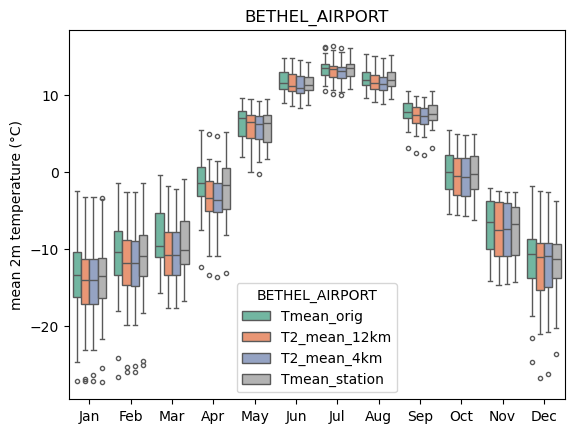

In [ ]:
g = sns.boxplot(data=df_forplot, x="month", y="meanT", 
            hue=teststation, palette=palette, legend=True, fliersize=3)
g.set_xticklabels(month_abbr)
g.set_xlabel('')
g.set_ylabel('mean 2m temperature (°C)')
g.set_title(teststation)

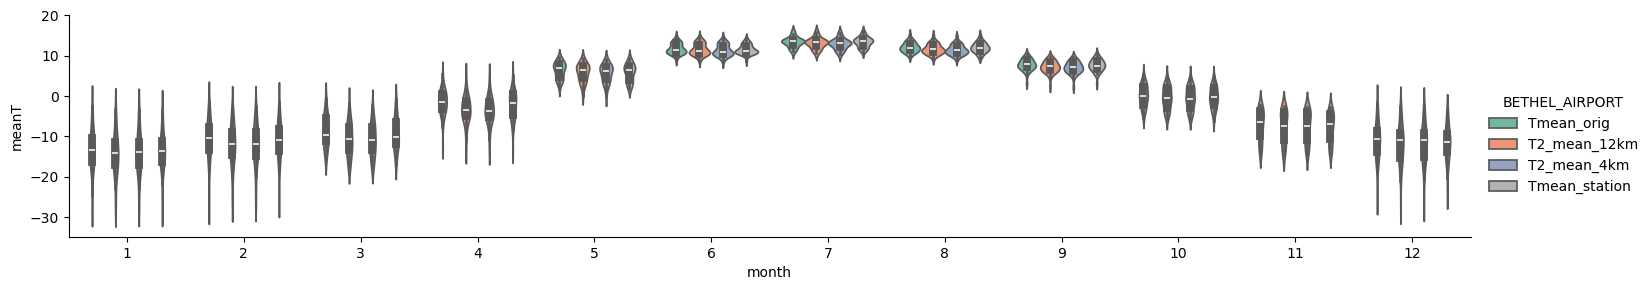

In [ ]:
g = sns.catplot(data=df_forplot, kind="violin", x="month", y="meanT", 
            hue=teststation, palette=palette, height=3, aspect=5)


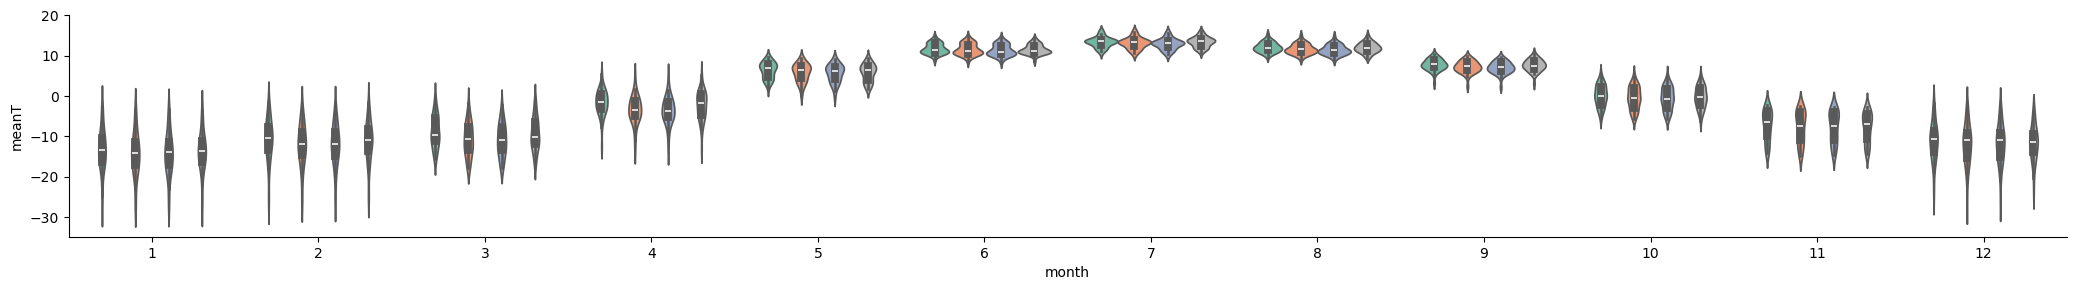

In [ ]:
g = sns.catplot(data=df_forplot, kind="violin", x="month", y="meanT", 
            hue=teststation, palette=palette, height=3, aspect=7)
g._legend.remove()

<Axes: xlabel='Time'>

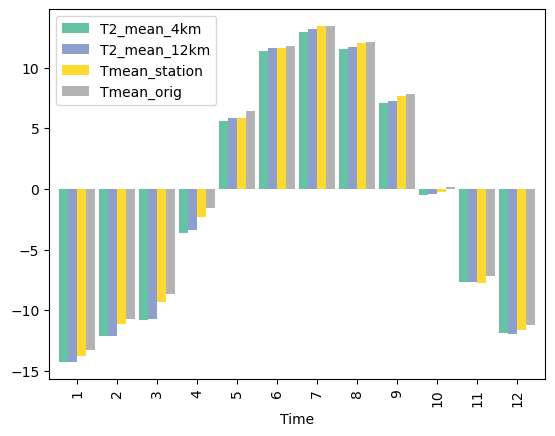

In [ ]:
monthly_DF.drop(columns=['month', 'year']).groupby(monthly_DF.index.month).mean().plot(
    kind='bar', width=0.9, cmap='Set2')

### Make all plots and statistics

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_68903/2358318720.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_68903/2359540524.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_68903/2358318720.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_68903/2359540524.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_68903/2358318720.py:4: FutureWa

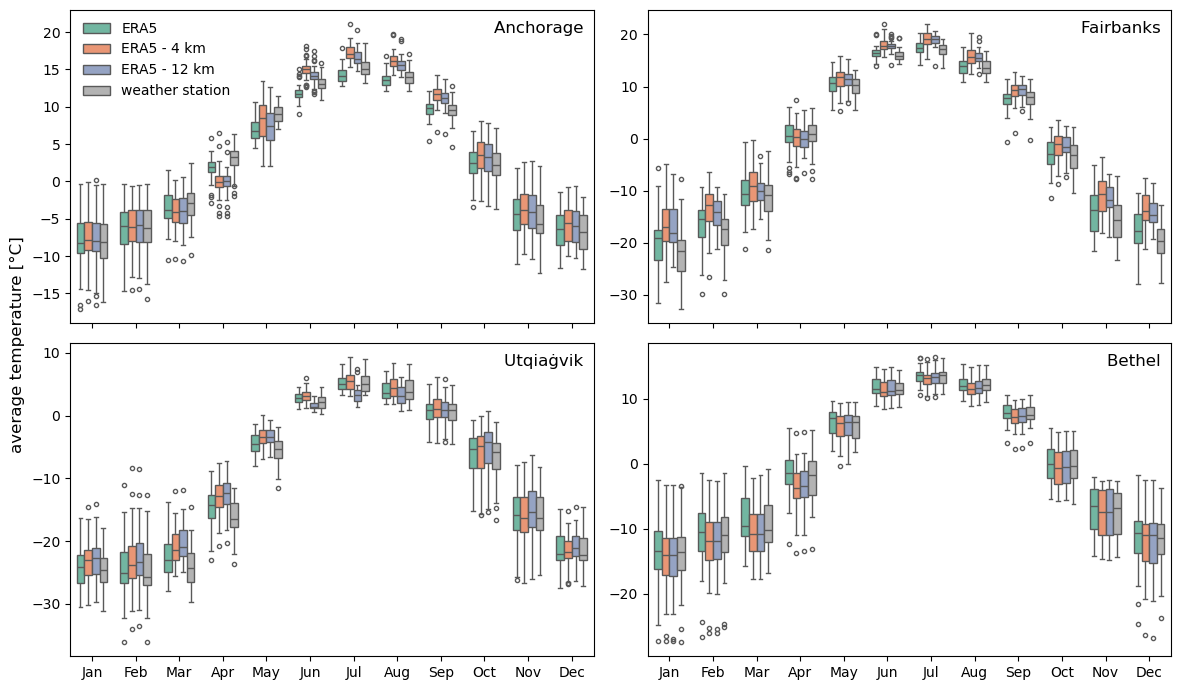

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 7), sharex=True)

results = []
for ii, (ax, station) in enumerate(zip(axes.flatten(), stations)):
    compDF = get_dataframe(station)
    locationname = get_name(station.replace('_', ' '))
    monthly_DF = get_monthly(compDF)
    monthly_undownscaled = pd.read_csv(datadir / filepattern_ERA5_orig.format(
    airport=stations[station][4:]), skiprows=2)
    monthly_DF['Tmean_orig'] = monthly_undownscaled['t2m'].values 
    monthly_DF.index.name = 'Time'
    # results.extend(get_stats(station, monthly_DF))
    df_forplot = pd.melt(monthly_DF.reset_index(), id_vars=[monthly_DF.index.name, 'year', 'month'], 
        value_vars=['Tmean_orig', 'T2_mean_4km', 'T2_mean_12km', 'Tmean_station'], value_name='meanT', var_name=station)
    g = sns.boxplot(data=df_forplot, x="month", y="meanT", 
            hue=station, palette=palette, width=0.7, fliersize=3, ax=ax)
    ax.get_legend().remove()  
    g.set_xticklabels(month_abbr)
    g.set_xlabel('')
    g.set_ylabel('')
    ax.set_title(locationname + '  ' , loc='right', y=0.9)
fig.supylabel('average temperature [°C]')
handles, _ = ax.get_legend_handles_labels()
labels = ['ERA5', 'ERA5 - 4 km', 'ERA5 - 12 km', 'weather station']
fig.legend(handles, labels, loc='upper left', ncol=1, bbox_to_anchor=(0.07, 0.98), frameon=False)
plt.tight_layout()

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_68903/2358318720.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_68903/733239700.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_68903/2358318720.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_68903/733239700.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_68903/2358318720.py:4: FutureWarn

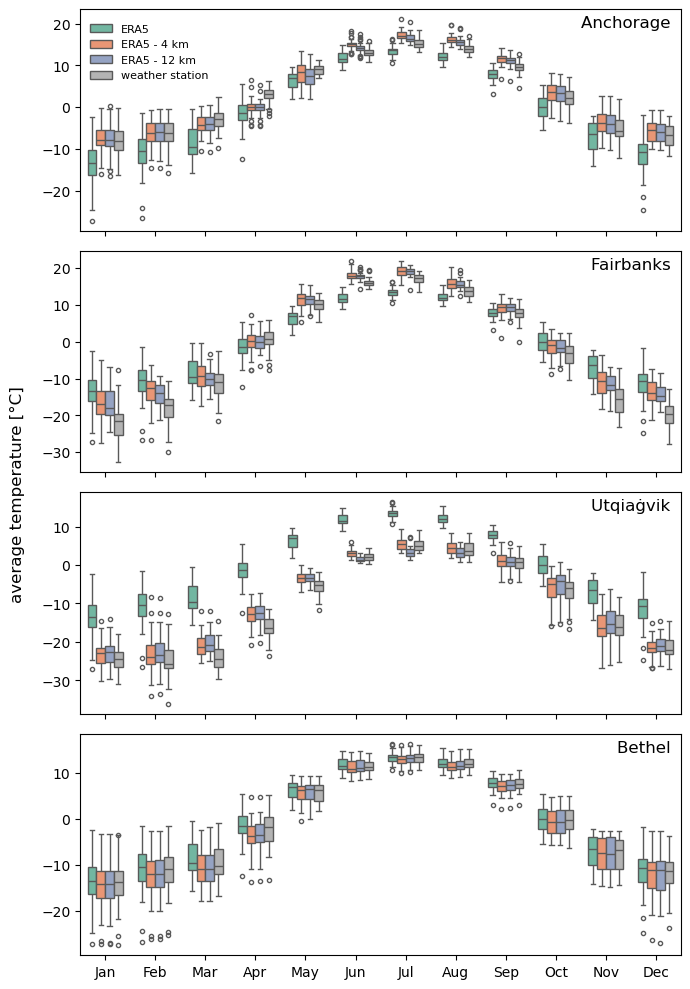

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(7, 10), sharex=True)

results = []
for ii, (ax, station) in enumerate(zip(axes.flatten(), stations)):
    compDF = get_dataframe(station)
    locationname = get_name(station.replace('_', ' '))
    monthly_DF = get_monthly(compDF)
    monthly_undownscaled = pd.read_csv(datadir / filepattern_ERA5_orig.format(
    airport=stations[teststation][4:]), skiprows=2)
    monthly_DF['Tmean_orig'] = monthly_undownscaled['t2m'].values 
    monthly_DF.index.name = 'Time'
    # results.extend(get_stats(station, monthly_DF))
    df_forplot = pd.melt(monthly_DF.reset_index(), id_vars=[monthly_DF.index.name, 'year', 'month'], 
        value_vars=['Tmean_orig', 'T2_mean_4km', 'T2_mean_12km', 'Tmean_station'], value_name='meanT', var_name=station)
    g = sns.boxplot(data=df_forplot, x="month", y="meanT", 
            hue=station, palette=palette, width=0.7, fliersize=3, ax=ax)
    ax.get_legend().remove()  
    g.set_xticklabels(month_abbr)
    g.set_xlabel('')
    g.set_ylabel('')
    # if not ii==1:
    #     g.set_ylabel('')
    # else:
    #     g.set_ylabel('2m temperature (°C)')
    # if ii>0:
    #     ax.set_title('  ' + locationname, loc='left', y=0.9)
    # else:
    ax.set_title(locationname + '  ' , loc='right', y=0.88)
handles, _ = ax.get_legend_handles_labels()
labels = ['ERA5', 'ERA5 - 4 km', 'ERA5 - 12 km', 'weather station']
fig.supylabel('average temperature [°C]')
fig.legend(handles, labels, 
           loc='upper left', ncol=1, bbox_to_anchor=(0.12, 0.98), 
           fontsize=8, frameon=False)
plt.tight_layout()

In [ ]:
fn = f"t{agg}_stations_monthly_distribution_box_{startdate[:4]}-{enddate[:4]}.png"
fig.savefig(figdir / fn, bbox_inches='tight', dpi=300)

In [ ]:
results = []
for station in stations:
    compDF = get_dataframe(station)
    location = stations[station]
    monthly_DF = get_monthly(compDF)
    monthly_undownscaled = pd.read_csv(datadir / filepattern_ERA5_orig.format(
        airport=stations[teststation][4:]), skiprows=2)
    monthly_DF['Tmean_orig'] = monthly_undownscaled['t2m'].values 
    monthly_DF.index.name = 'Time'
    results.extend(get_stats(station, monthly_DF, kind='mannkendall'))

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_68903/2358318720.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_68903/2358318720.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_68903/2358318720.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_68903/2358318720.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()


In [ ]:
monthly_DF

,T2_mean_4km,T2_mean_12km,Tmean_station,year,month,Tmean_orig
Time,,,,,,
1981-01-31,-6.313000,-6.329065,-6.191756,1981,1,-5.198
1981-02-28,-13.875893,-14.127536,-10.902778,1981,2,-10.301
1981-03-31,-3.934419,-3.968516,-1.424731,1981,3,-0.923
1981-04-30,-3.425200,-2.889567,0.138889,1981,4,0.218
1981-05-31,8.709161,8.905419,8.942652,1981,5,9.469
...,...,...,...,...,...,...
2020-08-31,12.939710,13.169839,13.055556,2020,8,13.280
2020-09-30,7.028133,7.181000,7.407407,2020,9,7.462
2020-10-31,2.076032,2.159710,2.249104,2020,10,2.638


In [ ]:
resultsDF = pd.DataFrame.from_records(results)
resultsDF['trend'] = resultsDF['trend'] * 10
resultsDF

,location,variable,month,mean_monthly,std_monthly,rmse_monthly,bias_monthly,trend,p_value,kendall_tau,r_value
0,PANC,Tmean_orig,1,-13.279675,5.320431,6.061294,-5.179317,-0.012590,0.972117,-0.005128,None
1,PANC,Tmean_orig,2,-10.747375,5.308031,6.180008,-4.428512,1.143344,0.074650,0.197436,None
2,PANC,Tmean_orig,3,-8.632825,3.916446,6.274738,-5.605271,-0.566250,0.369650,-0.100000,None
3,PANC,Tmean_orig,4,-1.597275,3.193154,4.989096,-4.494497,0.747857,0.074650,0.197436,None
4,PANC,Tmean_orig,5,6.424325,2.011546,2.827177,-2.520343,0.527857,0.057549,0.210256,None
...,...,...,...,...,...,...,...,...,...,...,...
187,PABE,Tmean_station,8,12.072013,1.282616,NaN,NaN,0.299404,0.118442,0.173077,None
188,PABE,Tmean_station,9,7.666667,1.481615,NaN,NaN,0.400362,0.093374,0.185897,None
189,PABE,Tmean_station,10,-0.253584,2.607891,NaN,NaN,1.032706,0.002646,0.332051,None
190,PABE,Tmean_station,11,-7.762269,3.594217,NaN,NaN,0.576706,0.263257,0.124359,None


In [ ]:
meansdf = resultsDF.pivot(columns=['variable'], index=['location', 'month',], values='mean_monthly').reset_index()
meansdf['Bias_ERA5'] = meansdf['Tmean_station'] - meansdf['Tmean_orig']
meansdf['Bias_4km'] = meansdf['Tmean_station'] - meansdf['T2_mean_4km']
meansdf['Bias_12km'] = meansdf['Tmean_station'] - meansdf['T2_mean_12km']
# biasdf = meansdf.drop(columns=[['T2_mean_12km', 'T2_mean_4km', 'Tmean_orig']], axis=0)
meansdf

variable,location,month,T2_mean_12km,T2_mean_4km,Tmean_orig,Tmean_station,Bias_ERA5,Bias_4km,Bias_12km
0,PABE,1,-14.290424,-14.245404,-13.279675,-13.747636,-0.467961,0.497768,0.542788
1,PABE,2,-12.116456,-12.114680,-10.747375,-11.168403,-0.421028,0.946278,0.948054
2,PABE,3,-10.727250,-10.816811,-8.632825,-9.304211,-0.671386,1.512600,1.423039
3,PABE,4,-3.409309,-3.647453,-1.597275,-2.330423,-0.733148,1.317030,1.078886
4,PABE,5,5.836269,5.634044,6.424325,5.824597,-0.599728,0.190552,-0.011672
5,PABE,6,11.633823,11.410818,11.803700,11.617412,-0.186288,0.206594,-0.016411
6,PABE,7,13.181385,12.965017,13.427050,13.429518,0.002468,0.464501,0.248132
7,PABE,8,11.712121,11.511432,12.149600,12.072013,-0.077587,0.560581,0.359892
8,PABE,9,7.262433,7.103608,7.819175,7.666667,-0.152508,0.563059,0.404233
9,PABE,10,-0.416702,-0.517216,0.148375,-0.253584,-0.401959,0.263632,0.163118


In [ ]:
tableDF = resultsDF.query('variable != "ERA5-12km"')
tableDF['ID'] = tableDF.location + ': ' + tableDF['variable']
tableDF['strtrend'] = tableDF['trend'].round(2).astype(str) 
tableDF['sigtrend'] = tableDF['strtrend'] + tableDF['p_value'].apply(add_significance_suffix)

In [ ]:
sigtable = tableDF.pivot(index='ID', columns='month', values='sigtrend')
sigtable.columns = [calendar.month_abbr[ii] for ii in sigtable.columns]
sigtable

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
ID,,,,,,,,,,,,
PABE: T2_mean_12km,0.2,1.57 (**),-0.64,0.81,0.69 (**),0.38,0.12,0.3,0.32,1.12 (**),0.68,0.24
PABE: T2_mean_4km,0.19,1.58 (**),-0.65,0.85,0.7 (**),0.37,0.13,0.3,0.33,1.13 (**),0.69,0.16
PABE: Tmean_orig,-0.01,1.14 (*),-0.57,0.75 (*),0.53 (*),0.28,0.12,0.29,0.33,1.08 (**),0.61,0.01
PABE: Tmean_station,0.03,1.04 (*),-0.62,0.9 (*),0.69 (**),0.28,0.2,0.3,0.4 (*),1.03 (**),0.58,-0.08
PABR: T2_mean_12km,0.61,1.22 (*),0.93 (**),1.16 (**),0.5 (**),-0.02,0.34 (**),0.73 (**),1.15 (**),2.21 (**),2.86 (**),0.84 (**)
PABR: T2_mean_4km,0.67,1.23 (*),0.92 (**),1.19 (**),0.56 (**),0.02,0.31,0.54 (**),1.11 (**),2.28 (**),2.72 (**),0.78 (*)
PABR: Tmean_orig,-0.01,1.14 (*),-0.57,0.75 (*),0.53 (*),0.28,0.12,0.29,0.33,1.08 (**),0.61,0.01
PABR: Tmean_station,0.9 (**),1.52 (**),0.89 (**),1.16 (**),0.7 (**),0.13,0.54 (**),0.57 (**),1.04 (**),2.01 (**),2.72 (**),0.98 (**)
PAFA: T2_mean_12km,0.41,1.39 (**),0.24,0.98 (**),0.76 (**),0.16,0.02,0.21,0.32 (**),1.26 (**),1.18 (**),0.22


In [ ]:
rmsetable = tableDF.pivot(index='ID', columns='month', values='rmse_monthly')
rmsetable.columns = [calendar.month_abbr[ii] for ii in rmsetable.columns]
rmsetable.dropna(inplace=True)
rmsetable

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
ID,,,,,,,,,,,,
PABE: T2_mean_12km,1.308432,1.426136,1.795415,1.577151,0.705978,0.526264,0.452923,0.532648,0.510630,0.466298,0.817436,1.158075
PABE: T2_mean_4km,1.235764,1.384360,1.849214,1.747271,0.743247,0.551574,0.593471,0.679040,0.641217,0.513310,0.765672,1.024429
PABE: Tmean_orig,0.813000,0.738089,0.861433,1.018455,0.723089,0.435560,0.304479,0.292773,0.318696,0.506254,0.723696,0.823307
PABR: T2_mean_12km,2.165894,2.563719,3.653099,3.855321,2.314184,0.815633,2.028054,1.210837,0.607957,1.551195,1.152633,1.075602
PABR: T2_mean_4km,1.827109,2.223350,3.151761,3.455069,2.275547,1.241058,0.728408,0.750304,0.700278,1.056952,0.870924,0.798931
PABR: Tmean_orig,11.922855,14.555602,15.701445,14.894256,12.156939,9.782474,8.410204,8.312837,7.553710,7.790374,9.816665,11.282518
PAFA: T2_mean_12km,8.509975,6.338392,5.301118,4.016495,2.800151,2.289920,2.306024,2.791060,2.973612,3.981102,6.284671,6.800730
PAFA: T2_mean_4km,5.762615,4.712356,2.225858,1.603964,1.549777,2.044255,2.148595,1.983518,1.549479,2.110289,4.861941,6.013656
PAFA: Tmean_orig,9.149271,7.999266,3.749936,3.159300,3.837822,4.450992,3.905294,2.014267,1.163808,3.965276,9.259059,9.027273


In [ ]:
biastable = tableDF.pivot(index='ID', columns='month', values='bias_monthly')
biastable.columns = [calendar.month_abbr[ii] for ii in biastable.columns]
biastable.dropna(inplace=True)
biastable

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
ID,,,,,,,,,,,,
PABE: T2_mean_12km,-0.542788,-0.948054,-1.423039,-1.078886,0.011672,0.016411,-0.248132,-0.359892,-0.404233,-0.163118,0.081978,-0.324545
PABE: T2_mean_4km,-0.497768,-0.946278,-1.512600,-1.317030,-0.190552,-0.206594,-0.464501,-0.560581,-0.563059,-0.263632,0.079649,-0.239724
PABE: Tmean_orig,0.467961,0.421028,0.671386,0.733148,0.599728,0.186288,-0.002468,0.077587,0.152508,0.401959,0.546444,0.389643
PABR: T2_mean_12km,1.674126,2.357603,3.540524,3.802839,2.138706,-0.572752,-1.926985,-0.866497,0.232996,1.349792,0.684555,0.752240
PABR: T2_mean_4km,1.224345,1.965108,3.023039,3.392147,2.119703,1.082908,0.324867,0.439500,0.450801,0.710533,-0.106268,0.219258
PABR: Tmean_orig,11.237798,14.020824,15.313412,14.691614,11.982569,9.666200,8.234846,8.073435,7.375194,7.272031,8.930703,10.407116
PAFA: T2_mean_12km,4.891002,3.839280,1.434923,-0.778837,1.215306,1.702540,1.843096,1.840439,1.584806,2.059018,4.245271,5.141913
PAFA: T2_mean_4km,5.581827,4.495580,1.827959,-0.626086,1.278777,1.975882,2.095831,1.908117,1.503460,1.980527,4.662891,5.869332
PAFA: Tmean_orig,8.656929,7.339148,2.583797,-2.181766,-3.641983,-4.263661,-3.732448,-1.636466,0.279129,3.650839,8.725842,8.320871


In [ ]:
sigtable = tableDF.pivot(index='ID', columns='month', values='sigtrend')
sigtable.columns = [calendar.month_abbr[ii] for ii in sigtable.columns]
sigtable

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
ID,,,,,,,,,,,,
PABE: T2_mean_12km,0.05,1.54 (**),-0.48,1.05 (**),0.58 (*),0.43 (**),0.11,0.3 (*),0.35 (*),1.19 (**),0.69,0.15
PABE: T2_mean_4km,0.03,1.52 (**),-0.49,1.07 (**),0.58 (*),0.42 (**),0.11,0.3 (*),0.36 (*),1.19 (**),0.68,0.12
PABE: Tmean,-0.16,1.35 (*),-0.57,0.93 (**),0.49 (*),0.36 (**),0.12,0.28,0.33 (*),1.07 (**),0.5,-0.06
PABE: Tmean_C,-0.11,1.22 (*),-0.61,0.93 (*),0.59 (**),0.42 (**),0.15,0.31 (*),0.36 (*),1.04 (**),0.45,-0.01
PABR: T2_mean_12km,0.48,0.96,1.0 (**),1.16 (**),0.46 (**),0.02,0.47 (**),0.71 (**),1.18 (**),2.65 (**),2.85 (**),0.9 (**)
PABR: T2_mean_4km,0.5,1.01,1.02 (**),1.19 (**),0.51 (**),0.05,0.34,0.51 (**),1.16 (**),2.65 (**),2.74 (**),0.85 (**)
PABR: Tmean,-0.16,1.35 (*),-0.57,0.93 (**),0.49 (*),0.36 (**),0.12,0.28,0.33 (*),1.07 (**),0.5,-0.06
PABR: Tmean_C,0.81 (*),1.24 (**),1.09 (**),1.21 (**),0.68 (**),0.18,0.47 (**),0.55 (**),1.06 (**),2.34 (**),2.65 (**),1.03 (**)
PAFA: T2_mean_12km,0.42,1.31 (**),0.42,0.9 (**),0.78 (**),0.11,-0.13,0.16,0.35 (*),1.21 (**),1.14 (**),0.19
